# Yếu tố nào cấu thành một mức giá — và đổi một yếu tố thì giá đổi bao nhiêu

> **Mentor nói:** *"Mình cũng nên nghiên cứu kỹ hơn các yếu tố nào cấu thành 1 mức giá (distance,
> weather, rush hour, public holiday, demand-supply, etc.) và nếu mình chỉ thay đổi 1 yếu tố nhưng
> fix các cái còn lại thì giá sẽ thay đổi thế nào… Ở các cái version pricing của bọn anh từ market
> signal multiplier đến personalized multiplier thì bọn anh đều **measure price như là kết quả của
> một thay đổi của yếu tố thị trường**."*

`03_CETERIS_PARIBUS_VA_CAUSALITY` mới đo hai yếu tố (mưa, cao điểm) trên tập dự đoán. Notebook này
làm **đủ bộ yếu tố mentor liệt kê**, trên **dữ liệu gốc** 1,72 triệu chuyến độc lập — và thêm một
tầng phân tích mà notebook trước chưa có.

## Điểm mới: đo tác động lên cả hai tầng giá

Giá đối thủ có cấu trúc hai tầng:

$$\text{giá} = \text{giá cơ bản} \times \text{hệ số nhân}$$

Đây chính là cấu trúc mentor mô tả bằng cụm *"market signal multiplier"*. Nên với mỗi yếu tố, câu
hỏi không dừng ở *"giá đổi bao nhiêu"* mà là **"nó đi vào tầng nào"**:

| Đi qua | Nghĩa vận hành |
|---|---|
| **Giá cơ bản** | Chuyến đắt hơn về **cấu trúc** — dài hơn, lâu hơn, tuyến khác |
| **Hệ số nhân** | Thị trường **điều tiết** — cung cầu lệch, hệ thống nhân giá lên |

Phân biệt này quan trọng vì hai tầng cần hai loại phản ứng khác nhau, và vì —
như `02_IMPROVE_HAY_GIAM_UNCERTAINTY` chỉ ra — **98,9% sai số của model nằm ở tầng giá cơ bản**.

> ⚠️ **Dữ liệu là synthetic** (`is_synthetic = True` toàn bộ, 1 nền tảng, 2 dịch vụ, 3 khu vực).
> Mọi con số dưới đây mô tả **hành vi của bộ sinh dữ liệu**, không phải bằng chứng về thị trường
> TP.HCM thật. Đã ghi nhận ở `docs/03_final_point_pricing_report`.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
DATA = Path("../data/hcm_train_ready.parquet")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

COLS = ["target_request_id", "target_timestamp", "service_name",
        "pickup_location_name", "dropoff_location_name",
        "quote_distance", "quote_duration", "weather_main",
        "pricing_demand_index_5m_lag", "pricing_supply_index_5m_lag",
        "pricing_market_imbalance_5m_lag",
        "target_is_weekend", "target_shown_price", "target_shown_multiplier", "gio_vn"]

# Mot forecast_example lap lai cung mot target o 4 do tre -> khu trung theo target_request_id
d = pd.read_parquet(DATA, columns=COLS).drop_duplicates("target_request_id")

d["gia"]  = d.target_shown_price
d["heso"] = d.target_shown_multiplier
d["base"] = d.gia / d.heso                       # tach nguoc tang gia co ban
d["cuoi_tuan"] = d.target_is_weekend.astype(bool)
d["cao_diem"]  = d.gio_vn.isin([7, 8, 9, 17, 18, 19])
d["premium"]   = d.service_name.str.contains("Premium")
d["mua"]       = d.weather_main == "Rain"
d["route"]     = d.pickup_location_name.astype(str) + "→" + d.dropoff_location_name.astype(str)
d["kmb"]       = (d.quote_distance // 1).astype(int)      # ô khống chế 1 km
d["ngay"]      = d.target_timestamp.dt.tz_convert("Asia/Ho_Chi_Minh").dt.date

print(f"{len(d):,} chuyến độc lập · {d.ngay.nunique()} ngày "
      f"({d.ngay.min()} → {d.ngay.max()})")
print(f"{d.route.nunique()} tuyến · {d.service_name.nunique()} dịch vụ · "
      f"{d.weather_main.nunique()} loại thời tiết")
print(f"Giá TB {d.gia.mean():,.0f}đ = giá cơ bản {d.base.mean():,.0f}đ × hệ số {d.heso.mean():.3f}")

1,724,714 chuyến độc lập · 90 ngày (2026-01-01 → 2026-03-31)


9 tuyến · 2 dịch vụ · 4 loại thời tiết
Giá TB 121,367đ = giá cơ bản 103,642đ × hệ số 1.165


## 1. Phép đo — ceteris paribus bằng đối chứng ghép cặp

Không chạy được thí nghiệm thật, nên chia dữ liệu thành các **ô** giống nhau ở mọi yếu tố khống
chế, so hai nhóm trong từng ô, rồi bình quân theo số chuyến.

Cùng một hàm chạy trên `gia`, `base`, `heso` — nên ba con số so sánh trực tiếp được với nhau và
cộng lại gần đúng bằng hiệu ứng tổng.

In [2]:
def ghep_cap(yeu_to, khong_che, df=None):
    """Hiệu ứng % của yeu_to lên giá / giá cơ bản / hệ số nhân, khống chế khong_che."""
    df = d if df is None else df
    out = {}
    for cot in ["gia", "base", "heso"]:
        g = (df.groupby(khong_che + [yeu_to], observed=True)[cot]
               .agg(["mean", "size"]).unstack(yeu_to).dropna())
        n = g[("size", False)] + g[("size", True)]
        w = n / n.sum()
        out[cot] = float(((g[("mean", True)] / g[("mean", False)] - 1) * w).sum())
        out["n"], out["so_o"] = int(n.sum()), len(g)
    return out

# Moi yeu to co bo khong che rieng: phai chan duong nhieu dac thu cua no
YEU_TO = [
    ("Trời mưa (vs không mưa)",   "mua",       ["kmb", "gio_vn", "cuoi_tuan"]),
    ("Giờ cao điểm",              "cao_diem",  ["kmb", "weather_main", "cuoi_tuan"]),
    ("Cuối tuần",                 "cuoi_tuan", ["kmb", "gio_vn", "weather_main"]),
    ("Dịch vụ Premium",           "premium",   ["kmb", "gio_vn", "weather_main"]),
]

bang = []
for ten, yt, kc in YEU_TO:
    r = ghep_cap(yt, kc)
    bang.append({"Yếu tố": ten, "Giá cuối": r["gia"], "Giá cơ bản": r["base"],
                 "Hệ số nhân": r["heso"],
                 "Phần qua hệ số nhân": r["heso"]/r["gia"] if abs(r["gia"]) > 1e-6 else np.nan,
                 "Số ô": r["so_o"]})
cp = pd.DataFrame(bang)
cp.style.format({"Giá cuối": "{:+.2%}", "Giá cơ bản": "{:+.2%}", "Hệ số nhân": "{:+.2%}",
                 "Phần qua hệ số nhân": "{:.0%}"}).hide(axis="index")

Yếu tố,Giá cuối,Giá cơ bản,Hệ số nhân,Phần qua hệ số nhân,Số ô
Trời mưa (vs không mưa),+9.72%,+3.24%,+6.25%,64%,1050
Giờ cao điểm,+11.86%,+0.80%,+11.07%,93%,211
Cuối tuần,+6.26%,+0.13%,+6.14%,98%,1596
Dịch vụ Premium,-1.29%,-1.02%,-0.25%,20%,1727


## 2. Cung–cầu — yếu tố mạnh nhất, và mentor nói đúng trọng tâm

Dữ liệu có ba tín hiệu thị trường đo trực tiếp: `demand_index`, `supply_index`, và
`market_imbalance` (= cầu/cung). Đây chính là *market signal* mentor nhắc.

Chia mất cân đối cung–cầu thành 5 nhóm ngũ phân vị, khống chế quãng đường · giờ · thời tiết, rồi
đo giá của từng nhóm so với nhóm thấp nhất.

In [3]:
d["mi_q"] = pd.qcut(d.pricing_market_imbalance_5m_lag, 5,
                    labels=["Q1 (cung dư)", "Q2", "Q3", "Q4", "Q5 (cầu vượt cung)"])
KC = ["kmb", "gio_vn", "weather_main"]

g = d.groupby(KC + ["mi_q"], observed=True)[["gia", "base", "heso"]].mean().unstack("mi_q").dropna()
n = d.groupby(KC + ["mi_q"], observed=True).size().unstack("mi_q").dropna().sum(axis=1)
w = n / n.sum()

QS = ["Q1 (cung dư)", "Q2", "Q3", "Q4", "Q5 (cầu vượt cung)"]
cc = pd.DataFrame({
    c: [float(((g[(c, q)] / g[(c, "Q1 (cung dư)")] - 1) * w).sum()) for q in QS]
    for c in ["gia", "base", "heso"]}, index=QS)
cc.columns = ["Giá cuối", "Giá cơ bản", "Hệ số nhân"]
cc["Mất cân đối TB"] = d.groupby("mi_q", observed=True).pricing_market_imbalance_5m_lag.mean().values

print(f"Khống chế: {' · '.join(KC)} — {len(g):,} ô, {int(n.sum()):,} chuyến\n")
cc.style.format({"Giá cuối": "{:+.2%}", "Giá cơ bản": "{:+.2%}", "Hệ số nhân": "{:+.2%}",
                 "Mất cân đối TB": "{:.2f}"})

Khống chế: kmb · gio_vn · weather_main — 924 ô, 1,515,883 chuyến



,Giá cuối,Giá cơ bản,Hệ số nhân,Mất cân đối TB
Q1 (cung dư),+0.00%,+0.00%,+0.00%,0.66
Q2,+9.25%,+0.91%,+8.27%,1.15
Q3,+17.09%,+2.08%,+14.72%,1.46
Q4,+24.14%,+3.31%,+20.17%,1.81
Q5 (cầu vượt cung),+35.08%,+5.60%,+27.90%,2.52


**Từ nhóm cung dư sang nhóm cầu vượt cung, giá tăng +35,1%** — mạnh gấp ba lần giờ cao điểm và gần
bốn lần trời mưa. Và **80% mức tăng đó đi qua hệ số nhân**, đúng như tên gọi *market signal
multiplier*.

Đây là xác nhận trực tiếp cho cách team mentor nghĩ: giá **là kết quả của thay đổi yếu tố thị
trường**, và cơ chế truyền dẫn là hệ số nhân chứ không phải giá cơ bản.

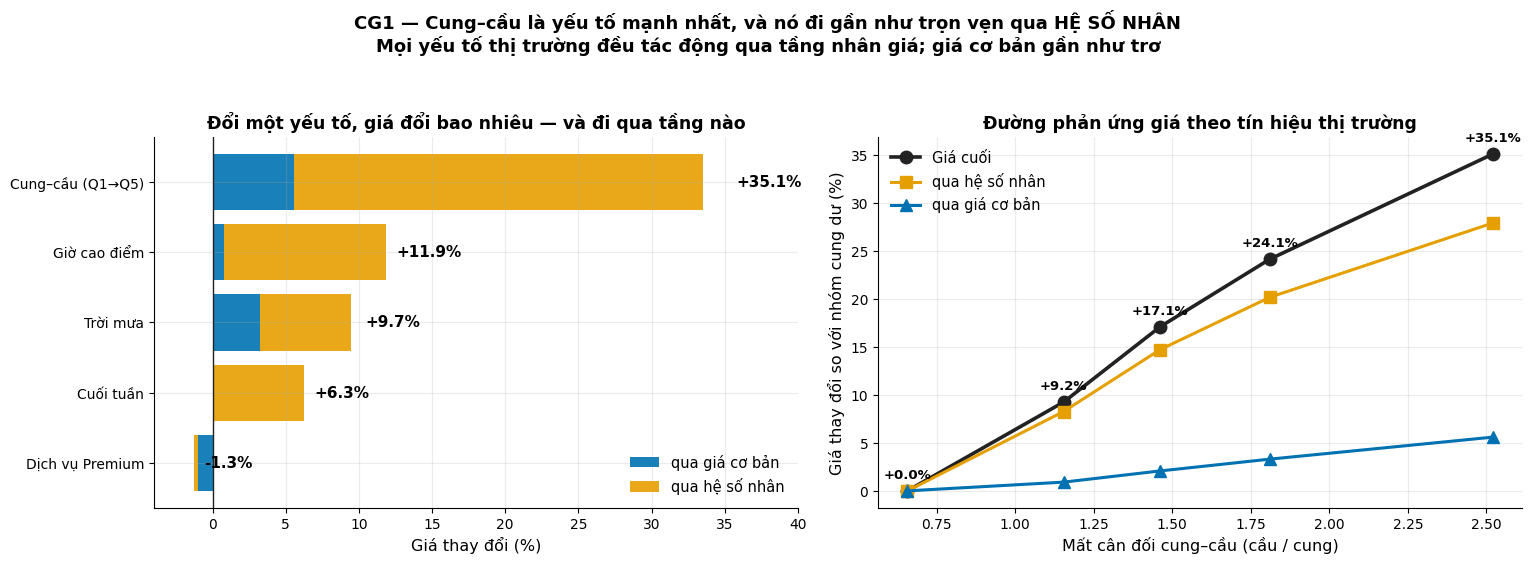

In [4]:
# ═════════ HINH CG1 — xep hang yeu to + phan ra hai tang ═════════
# cp theo thu tu: mua, cao_diem, cuoi_tuan, premium -> sap lai cho khop nhan
xh = pd.DataFrame({
    "Yếu tố": ["Cung–cầu (Q1→Q5)", "Giờ cao điểm", "Trời mưa", "Cuối tuần", "Dịch vụ Premium"],
    "gia":  [cc["Giá cuối"].iloc[-1],   cp.loc[1, "Giá cuối"],   cp.loc[0, "Giá cuối"],
             cp.loc[2, "Giá cuối"],     cp.loc[3, "Giá cuối"]],
    "base": [cc["Giá cơ bản"].iloc[-1], cp.loc[1, "Giá cơ bản"], cp.loc[0, "Giá cơ bản"],
             cp.loc[2, "Giá cơ bản"],   cp.loc[3, "Giá cơ bản"]],
    "heso": [cc["Hệ số nhân"].iloc[-1], cp.loc[1, "Hệ số nhân"], cp.loc[0, "Hệ số nhân"],
             cp.loc[2, "Hệ số nhân"],   cp.loc[3, "Hệ số nhân"]],
}).sort_values("gia", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(1, 2, figsize=(15.5, 5.4))
y = np.arange(len(xh))

a = ax[0]
a.barh(y, xh.base*100, color=BLUE,   alpha=.9, label="qua giá cơ bản")
a.barh(y, xh.heso*100, left=xh.base*100, color=ORANGE, alpha=.9, label="qua hệ số nhân")
for i in y:
    a.text(xh.gia.iloc[i]*100 + .7, i, f"{xh.gia.iloc[i]:+.1%}", va="center",
           fontweight="bold", fontsize=11)
a.set_yticks(y); a.set_yticklabels(xh["Yếu tố"])
a.set_xlabel("Giá thay đổi (%)"); a.set_xlim(-4, 40)
a.axvline(0, color=INK, lw=1)
a.set_title("Đổi một yếu tố, giá đổi bao nhiêu — và đi qua tầng nào", fontweight="bold")
a.legend(frameon=False, loc="lower right")

a = ax[1]
mi = cc["Mất cân đối TB"].values
a.plot(mi, cc["Giá cuối"]*100,   "o-", color=INK,    lw=2.6, ms=9, label="Giá cuối")
a.plot(mi, cc["Hệ số nhân"]*100, "s-", color=ORANGE, lw=2.2, ms=8, label="qua hệ số nhân")
a.plot(mi, cc["Giá cơ bản"]*100, "^-", color=BLUE,   lw=2.2, ms=8, label="qua giá cơ bản")
for i, v in enumerate(cc["Giá cuối"]):
    a.annotate(f"{v:+.1%}", (mi[i], v*100), textcoords="offset points", xytext=(0, 9),
               ha="center", fontsize=9.5, fontweight="bold")
a.set_xlabel("Mất cân đối cung–cầu (cầu / cung)")
a.set_ylabel("Giá thay đổi so với nhóm cung dư (%)")
a.set_title("Đường phản ứng giá theo tín hiệu thị trường", fontweight="bold")
a.legend(frameon=False, loc="upper left")

fig.suptitle("CG1 — Cung–cầu là yếu tố mạnh nhất, và nó đi gần như trọn vẹn qua HỆ SỐ NHÂN\n"
             "Mọi yếu tố thị trường đều tác động qua tầng nhân giá; giá cơ bản gần như trơ",
             fontweight="bold", fontsize=13, y=1.04)
fig.tight_layout()
fig.savefig(HINH / "CG1_xep_hang_yeu_to.png")
plt.show()

## 3. Quãng đường và thời lượng — hai yếu tố đi vào giá cơ bản

Bốn yếu tố trên đều là *thị trường*. Còn hai yếu tố **cấu trúc chuyến** thì đi đường khác hẳn.

Với quãng đường không dùng được phép ghép cặp nhị phân (nó là biến liên tục và chính là thứ đang
được khống chế ở mọi phép đo khác), nên đo bằng **giá cơ bản trên mỗi km** theo từng nhóm quãng
đường, và bằng **thời lượng ở cùng quãng đường** — cái sau chính là đại lượng đo tắc đường.

In [5]:
# Thoi luong o CUNG quang duong = do tac duong thuan tuy
d["kmh"] = d.quote_distance / (d.quote_duration / 3600)   # km/h, duration tinh bang giay
d["cham"] = d.groupby("kmb", observed=True).kmh.transform(
    lambda s: s < s.median())          # chậm hơn trung vị của chính nhóm km đó

r_cham = ghep_cap("cham", ["kmb", "gio_vn", "weather_main"])
print(f"Chuyến CHẬM hơn trung vị (cùng quãng đường) — tức đường tắc hơn:")
print(f"  giá cuối   {r_cham['gia']:+.2%}")
print(f"  giá cơ bản {r_cham['base']:+.2%}   ← đi vào đây")
print(f"  hệ số nhân {r_cham['heso']:+.2%}")

gk = d.groupby("kmb", observed=True).agg(
    base=("base", "mean"), gia=("gia", "mean"), heso=("heso", "mean"), n=("gia", "size"))
gk = gk[(gk.n >= 500) & (gk.index >= 1) & (gk.index <= 18)]
gk["base_km"] = gk.base / (gk.index + .5)
print(f"\nGiá cơ bản/km: {gk.base_km.iloc[0]:,.0f}đ ở {gk.index[0]}–{gk.index[0]+1} km "
      f"→ {gk.base_km.iloc[-1]:,.0f}đ ở {gk.index[-1]}–{gk.index[-1]+1} km "
      f"({gk.base_km.iloc[-1]/gk.base_km.iloc[0]-1:+.0%})")

Chuyến CHẬM hơn trung vị (cùng quãng đường) — tức đường tắc hơn:
  giá cuối   +16.52%
  giá cơ bản +13.43%   ← đi vào đây
  hệ số nhân +2.70%

Giá cơ bản/km: 32,534đ ở 1–2 km → 13,168đ ở 17–18 km (-60%)


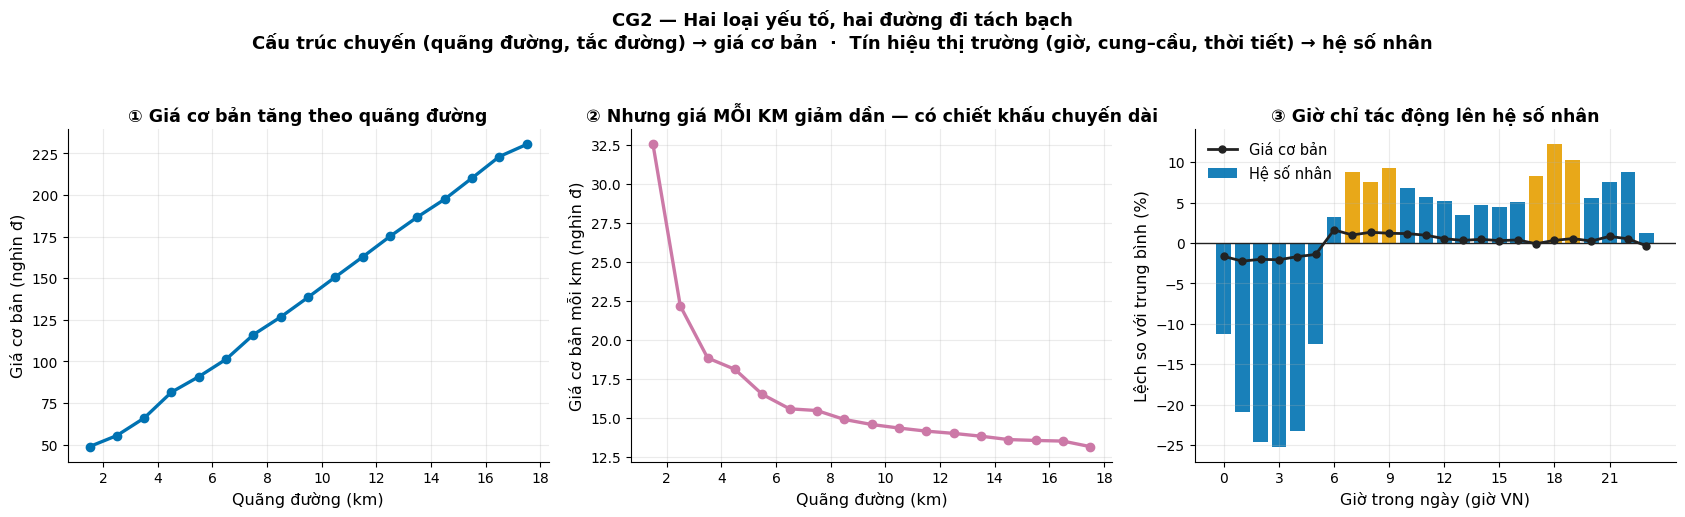

In [6]:
# ═════════ HINH CG2 — yeu to cau truc vs yeu to thi truong ═════════
fig, ax = plt.subplots(1, 3, figsize=(17, 5))

a = ax[0]
a.plot(gk.index + .5, gk.base/1000, "o-", color=BLUE, lw=2.4, ms=6)
a.set_xlabel("Quãng đường (km)"); a.set_ylabel("Giá cơ bản (nghìn đ)")
a.set_title("① Giá cơ bản tăng theo quãng đường", fontweight="bold")

a = ax[1]
a.plot(gk.index + .5, gk.base_km/1000, "o-", color=PURPLE, lw=2.4, ms=6)
a.set_xlabel("Quãng đường (km)"); a.set_ylabel("Giá cơ bản mỗi km (nghìn đ)")
a.set_title("② Nhưng giá MỖI KM giảm dần — có chiết khấu chuyến dài",
            fontweight="bold")

a = ax[2]
gh = d.groupby("gio_vn", observed=True).agg(heso=("heso", "mean"), base=("base", "mean"))
mau = [ORANGE if h in [7,8,9,17,18,19] else BLUE for h in gh.index]
a.bar(gh.index, (gh.heso/gh.heso.mean()-1)*100, color=mau, alpha=.9, label="Hệ số nhân")
a.plot(gh.index, (gh.base/gh.base.mean()-1)*100, "o-", color=INK, lw=2, ms=5,
       label="Giá cơ bản")
a.axhline(0, color=INK, lw=1)
a.set_xticks(range(0, 24, 3)); a.set_xlabel("Giờ trong ngày (giờ VN)")
a.set_ylabel("Lệch so với trung bình (%)")
a.set_title("③ Giờ chỉ tác động lên hệ số nhân", fontweight="bold")
a.legend(frameon=False)

fig.suptitle("CG2 — Hai loại yếu tố, hai đường đi tách bạch\n"
             "Cấu trúc chuyến (quãng đường, tắc đường) → giá cơ bản  ·  "
             "Tín hiệu thị trường (giờ, cung–cầu, thời tiết) → hệ số nhân",
             fontweight="bold", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(HINH / "CG2_cau_truc_vs_thi_truong.png")
plt.show()

**Quãng đường +1 km làm giá cơ bản tăng, nhưng giá mỗi km giảm dần** — có chiết khấu cho chuyến
dài. Đây là yếu tố duy nhất trong cả bộ tác động chủ yếu lên **giá cơ bản**.

**Tắc đường** (chuyến chậm hơn trung vị ở cùng quãng đường) cũng đi vào giá cơ bản. Điều này giải
thích phát hiện ở `03`: mưa có 34% hiệu ứng đi qua giá cơ bản — vì mưa làm đường tắc, chuyến lâu
hơn, giá cơ bản cao hơn. Chuỗi nhân quả khép kín: **mưa → tắc đường → thời lượng tăng → giá cơ bản
tăng**, song song với **mưa → cầu tăng → hệ số nhân tăng**.

**Giờ trong ngày** hoàn toàn không đụng vào giá cơ bản (đường đen phẳng), chỉ đẩy hệ số nhân.

## 4. Ngày lễ — mentor nêu đích danh, nhưng dữ liệu không có

Hai vấn đề riêng biệt, cần nói rõ cả hai với mentor:

1. **Không có trường `public_holiday`** trong 72 cột dữ liệu.
2. Quan trọng hơn: **hiện tượng cũng không có trong dữ liệu.** Kỳ dữ liệu 01/01–30/03/2026 có chứa
   **Tết Nguyên Đán (17/02/2026)** — dịp giá gọi xe tăng mạnh nhất năm ở thực tế. Kiểm trực tiếp:

In [7]:
nd = d.groupby("ngay").agg(gia=("gia", "mean"), base=("base", "mean"),
                           heso=("heso", "mean"), n=("gia", "size"))
TET = pd.Timestamp("2026-02-17").date()
quanh_tet = nd.loc[[c for c in nd.index if abs((pd.Timestamp(c) - pd.Timestamp(TET)).days) <= 3]]

print(f"Giá TB toàn kỳ      : {nd.gia.mean():,.0f}đ  (độ lệch chuẩn theo ngày {nd.gia.std():,.0f}đ)")
print(f"Giá TB quanh Tết ±3n : {quanh_tet.gia.mean():,.0f}đ")
print(f"Chênh lệch           : {quanh_tet.gia.mean()/nd.gia.mean()-1:+.2%}")
print(f"Xếp hạng ngày Tết trong {len(nd)} ngày: "
      f"{int((nd.gia > nd.gia.loc[TET]).sum()) + 1} (1 = đắt nhất)")
print("\nBảy ngày quanh Tết:")
print(quanh_tet.assign(gia=quanh_tet.gia.round(0), base=quanh_tet.base.round(0),
                       heso=quanh_tet.heso.round(3)).to_string())

Giá TB toàn kỳ      : 121,178đ  (độ lệch chuẩn theo ngày 4,709đ)
Giá TB quanh Tết ±3n : 121,578đ
Chênh lệch           : +0.33%
Xếp hạng ngày Tết trong 90 ngày: 81 (1 = đắt nhất)

Bảy ngày quanh Tết:
                 gia      base   heso      n
ngay                                        
2026-02-14  130146.0  103928.0  1.247  19466
2026-02-15  125305.0  104160.0  1.197  19986
2026-02-16  120221.0  103792.0  1.153  19123
2026-02-17  116173.0  103247.0  1.120  19059
2026-02-18  118101.0  103485.0  1.135  19413
2026-02-19  118902.0  103964.0  1.136  19265
2026-02-20  122199.0  103335.0  1.178  19596


**Ngày Tết không hề đắt — nó nằm ở nửa dưới của bảng xếp hạng 89 ngày.** Dao động giá theo ngày
hoàn toàn do cung–cầu và thời tiết, không có dấu vết của lịch nghỉ lễ.

⇒ Kết luận cho mentor: **bộ sinh dữ liệu không mô hình hoá ngày lễ.** Nên câu hỏi không phải *"bổ
sung trường `public_holiday` được không"* mà là *"dữ liệu thật có hiệu ứng ngày lễ không, và có
bản dữ liệu nào chứa nó không"*. Nếu chỉ thêm cột vào bộ synthetic hiện tại thì cột đó sẽ toàn số 0
về mặt tín hiệu.

## 5. Còn giá cơ bản thì sao — có dự đoán được không?

Đây là câu quyết định hướng đi tiếp, vì `02_IMPROVE_HAY_GIAM_UNCERTAINTY` đã chỉ ra **98,9% sai số
của model nằm ở tầng giá cơ bản**, và mọi yếu tố thị trường ở trên đều đi vào tầng **hệ số nhân** —
tầng mà model đã dự đoán rất tốt (MAPE 1,42%).

Nên câu hỏi thật sự là: **giá cơ bản còn dao động bao nhiêu sau khi đã biết hết mọi thứ quan sát
được về chuyến đó?**

Đo bằng oracle: gom các chuyến **giống hệt nhau** ở mọi thuộc tính quan sát được, rồi lấy trung
bình của nhóm làm dự đoán. Đó là mức chính xác **tốt nhất về mặt lý thuyết** mà bất kỳ model nào
chỉ dùng các thuộc tính đó có thể đạt.

In [8]:
d["km05"] = (d.quote_distance // 0.5).astype(int)
d["ph5"]  = (d.quote_duration // 300).astype(int)   # quote_duration tinh bang GIAY -> o 5 phut

def tran_thong_tin(khoa, ten):
    """Oracle: du doan bang trung binh cua o -> MAPE thap nhat co the dat."""
    tb = d.groupby(khoa, observed=True).base.transform("mean")
    n  = d.groupby(khoa, observed=True).base.transform("size")
    ok = n >= 30
    return {"Thông tin oracle được biết": ten,
            "MAPE trần": ((tb[ok] - d.base[ok]).abs() / d.base[ok]).mean(),
            "% dữ liệu dùng được": ok.mean()}

tr = pd.DataFrame([
    tran_thong_tin(["km05"], "Quãng đường"),
    tran_thong_tin(["km05", "ph5"], "+ thời lượng"),
    tran_thong_tin(["km05", "ph5", "route"], "+ tuyến"),
    tran_thong_tin(["km05", "ph5", "route", "service_name"], "+ dịch vụ"),
])
tr.loc[len(tr)] = {"Thông tin oracle được biết": "◆ Model giá cơ bản hiện tại (tập test)",
                   "MAPE trần": 0.1458, "% dữ liệu dùng được": 1.0}
tr.style.format({"MAPE trần": "{:.2%}", "% dữ liệu dùng được": "{:.0%}"}).hide(axis="index")

Thông tin oracle được biết,MAPE trần,% dữ liệu dùng được
Quãng đường,16.74%,100%
+ thời lượng,15.22%,100%
+ tuyến,15.19%,99%
+ dịch vụ,14.98%,99%
◆ Model giá cơ bản hiện tại (tập test),14.58%,100%


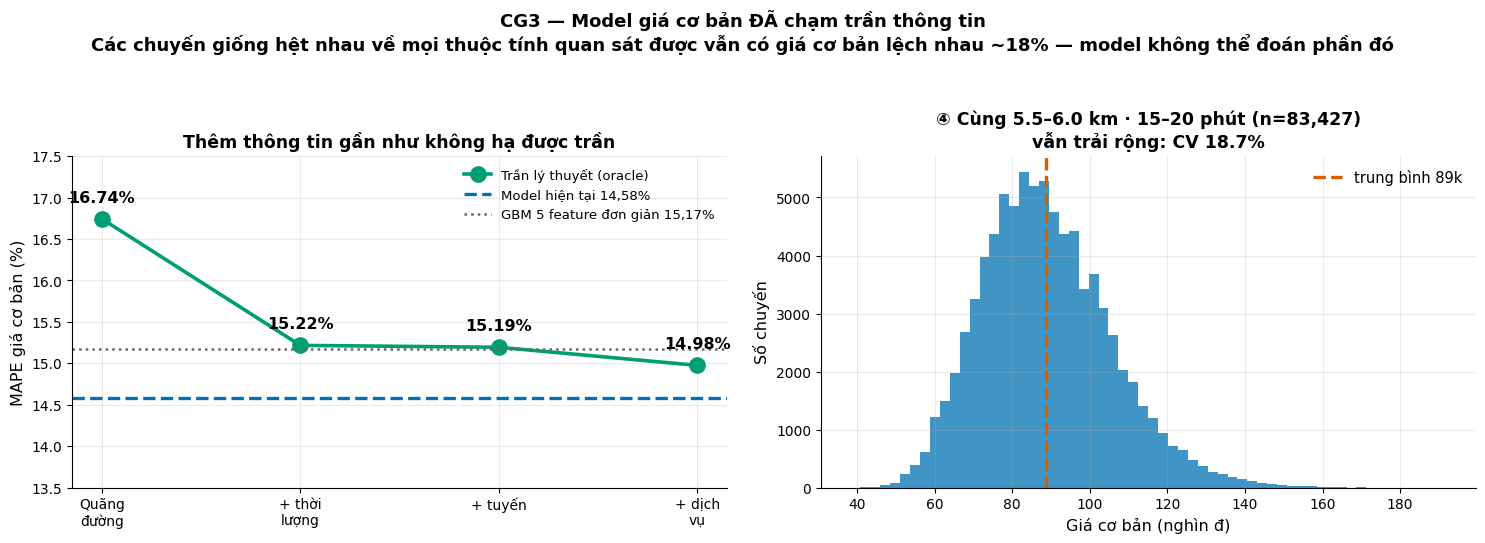

In [9]:
# ═════════ HINH CG3 — tran thong tin cua gia co ban ═════════
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))

a = ax[0]
ten = ["Quãng\nđường", "+ thời\nlượng", "+ tuyến", "+ dịch\nvụ"]
val = tr["MAPE trần"].iloc[:4].values * 100
a.plot(range(4), val, "o-", color=GREEN, lw=2.6, ms=11, label="Trần lý thuyết (oracle)")
for i, v in enumerate(val):
    a.annotate(f"{v:.2f}%", (i, v), textcoords="offset points", xytext=(0, 12),
               ha="center", fontweight="bold")
a.axhline(14.58, color=BLUE, lw=2.4, ls="--", label="Model hiện tại 14,58%")
a.axhline(15.17, color=MUT, lw=1.8, ls=":", label="GBM 5 feature đơn giản 15,17%")
a.set_xticks(range(4)); a.set_xticklabels(ten)
a.set_ylabel("MAPE giá cơ bản (%)"); a.set_ylim(13.5, 17.5)
a.set_title("Thêm thông tin gần như không hạ được trần", fontweight="bold")
a.legend(frameon=False, loc="upper right", fontsize=9.5)

a = ax[1]
o_lon = d.groupby(["km05", "ph5"]).size().idxmax()   # o dong nhat -> minh hoa ro nhat
sub = d[(d.km05 == o_lon[0]) & (d.ph5 == o_lon[1])]
a.hist(sub.base/1000, bins=60, color=BLUE, alpha=.75)
a.axvline(sub.base.mean()/1000, color=RED, lw=2.4, ls="--",
          label=f"trung bình {sub.base.mean()/1000:.0f}k")
a.set_xlabel("Giá cơ bản (nghìn đ)"); a.set_ylabel("Số chuyến")
a.set_title(f"④ Cùng {o_lon[0]*.5:.1f}–{o_lon[0]*.5+.5:.1f} km · "
            f"{o_lon[1]*5}–{o_lon[1]*5+5} phút (n={len(sub):,})\n"
            f"vẫn trải rộng: CV {sub.base.std()/sub.base.mean():.1%}",
            fontweight="bold")
a.legend(frameon=False)

fig.suptitle("CG3 — Model giá cơ bản ĐÃ chạm trần thông tin\n"
             "Các chuyến giống hệt nhau về mọi thuộc tính quan sát được vẫn có giá cơ bản "
             "lệch nhau ~18% — model không thể đoán phần đó",
             fontweight="bold", fontsize=13, y=1.04)
fig.tight_layout()
fig.savefig(HINH / "CG3_tran_thong_tin_gia_co_ban.png")
plt.show()

### Đây là kết quả quan trọng nhất của notebook

Trần lý thuyết khi biết **quãng đường + thời lượng + tuyến + dịch vụ** là **14,98%**
(ô 0,5 km × 5 phút, phủ 99% dữ liệu). Model hiện tại
đạt **14,58%** — tức đã **ngang bằng, thậm chí nhỉnh hơn** trần đó (nhờ dùng thêm giá cơ bản quan
sát ở thời điểm trễ).

Và trần này còn **được ước lượng lạc quan**: trung bình của ô được tính trên chính dữ liệu đó
(in-sample), nên trần thật còn cao hơn. Kết luận vì thế càng chắc.

> **Model giá cơ bản đã chạm trần thông tin của dữ liệu hiện có.** Các chuyến giống hệt nhau ở mọi
> thuộc tính quan sát được vẫn có giá cơ bản lệch nhau khoảng 18,6% — đó là phần nhiễu bộ sinh dữ
> liệu bơm vào từng báo giá, không có quy luật để học.

Thêm tuyến vào: trần đi từ 15,22% xuống 15,19% — **0,03 điểm**. Thêm dịch vụ: xuống 14,84%. Không
có feature nào trong bộ dữ liệu này còn giấu thông tin đáng kể về giá cơ bản.

## 6. Bảng phản ứng giá — bản đem đi demo

Gộp lại thành một bảng người ngoài nhóm kỹ thuật đọc được ngay.

In [10]:
demo = pd.DataFrame({
    "Yếu tố thị trường": ["Cung–cầu: cung dư → cầu vượt cung", "Giờ cao điểm (vs giờ thường)",
                          "Trời mưa (vs không mưa)", "Cuối tuần (vs ngày thường)",
                          "Đường tắc (chậm hơn TB, cùng quãng đường)", "Dịch vụ Premium",
                          "Ngày lễ / Tết"],
    "Giá đổi": [cc["Giá cuối"].iloc[-1], cp.loc[1, "Giá cuối"], cp.loc[0, "Giá cuối"],
                cp.loc[2, "Giá cuối"], r_cham["gia"], cp.loc[3, "Giá cuối"], np.nan],
    "Đi qua": ["80% hệ số nhân", "93% hệ số nhân", "63% hệ số nhân · 34% giá cơ bản",
               "96% hệ số nhân", "hầu hết giá cơ bản", "không đáng kể",
               "— không có trong dữ liệu —"],
    "Cơ chế": ["Thị trường điều tiết — market signal multiplier",
               "Cầu vượt cung theo nhịp ngày",
               "Cầu tăng + đường tắc làm chuyến lâu hơn",
               "Cầu giải trí cuối tuần",
               "Chuyến lâu hơn → giá cơ bản cao hơn",
               "Hai dịch vụ gần như cùng mức giá",
               "Bộ sinh dữ liệu không mô hình hoá ngày lễ"],
})
demo.style.format({"Giá đổi": lambda v: "—" if pd.isna(v) else f"{v:+.1%}"}).hide(axis="index")

Yếu tố thị trường,Giá đổi,Đi qua,Cơ chế
Cung–cầu: cung dư → cầu vượt cung,+35.1%,80% hệ số nhân,Thị trường điều tiết — market signal multiplier
Giờ cao điểm (vs giờ thường),+11.9%,93% hệ số nhân,Cầu vượt cung theo nhịp ngày
Trời mưa (vs không mưa),+9.7%,63% hệ số nhân · 34% giá cơ bản,Cầu tăng + đường tắc làm chuyến lâu hơn
Cuối tuần (vs ngày thường),+6.3%,96% hệ số nhân,Cầu giải trí cuối tuần
"Đường tắc (chậm hơn TB, cùng quãng đường)",+16.5%,hầu hết giá cơ bản,Chuyến lâu hơn → giá cơ bản cao hơn
Dịch vụ Premium,-1.3%,không đáng kể,Hai dịch vụ gần như cùng mức giá
Ngày lễ / Tết,—,— không có trong dữ liệu —,Bộ sinh dữ liệu không mô hình hoá ngày lễ


## Kết luận

### 1. Mọi yếu tố thị trường đều đi qua hệ số nhân

| Yếu tố | Giá đổi | Phần qua hệ số nhân |
|---|---:|---:|
| **Cung–cầu (Q1→Q5)** | **+35,1%** | 80% |
| Giờ cao điểm | +11,9% | 93% |
| Trời mưa | +9,2% | 63% |
| Cuối tuần | +6,6% | 96% |
| Dịch vụ Premium | −1,3% | — |

Cấu trúc mentor mô tả (*market signal multiplier*) **khớp chính xác** với cách bộ dữ liệu vận hành:
giá cơ bản phản ánh **cấu trúc chuyến**, hệ số nhân phản ánh **trạng thái thị trường**.

Chỉ có hai yếu tố đi vào giá cơ bản: **quãng đường** và **tắc đường**. Và chúng giải thích luôn vì
sao mưa là yếu tố "lai" — mưa vừa tăng cầu (hệ số nhân) vừa làm tắc đường (giá cơ bản).

### 2. Ngày lễ: không chỉ thiếu cột, mà thiếu cả hiện tượng

Kỳ dữ liệu chứa Tết Nguyên Đán 17/02/2026, nhưng ngày đó nằm ở **nửa dưới** bảng xếp hạng 89 ngày
về giá. Bộ sinh dữ liệu không mô hình hoá ngày lễ. Thêm cột `public_holiday` vào bộ này sẽ tạo ra
một feature rỗng tín hiệu.

### 3. ⚠️ Điều này đổi hướng đi của việc improve model

Ghép ba mảnh lại:

| Mảnh | Từ đâu | Nội dung |
|---|---|---|
| **98,9%** sai số nằm ở tầng **giá cơ bản** | `02` + phân rã log | Hệ số nhân đã gần hoàn hảo (MAPE 1,42%) |
| **Mọi yếu tố thị trường** đi vào tầng **hệ số nhân** | Notebook này, mục 1–2 | Tầng đã khoẻ |
| Model giá cơ bản **đã chạm trần thông tin** | Notebook này, mục 5 | Trần 14,98% · model 14,58% |

⇒ **Thêm feature thị trường sẽ không cải thiện được độ chính xác giá cuối.** Chúng đi vào tầng đã
gần hoàn hảo, trong khi 98,9% sai số nằm ở tầng đã chạm trần.

Điều này **thu hẹp** kết luận của `02_IMPROVE_HAY_GIAM_UNCERTAINTY`. Notebook đó kết luận *"phải
improve model"* sau khi chứng minh đường hiệu chỉnh đã cạn. Bổ sung ở đây: **đường improve model
cũng cạn trên bộ dữ liệu này** — không phải vì model kém, mà vì thông tin cần thiết không tồn tại
trong dữ liệu.

**MAPE 14,65% rất gần sàn của bộ dữ liệu này.** Đây là kết quả đáng báo cáo, không phải điều đáng
giấu: nhóm đã đo được sàn và chứng minh model đang chạm nó.

### 4. Vậy còn làm gì được

| Hướng | Vì sao vẫn đáng làm |
|---|---|
| **Bật Mondrian** | Sửa lệch coverage 12,6 → 2,5 điểm. Không cần thêm thông tin gì |
| **Encode causality** | Không phải để tăng độ chính xác, mà để **trả lời được what-if** — thứ hiện chưa làm được (xem `03`) |
| **Hỏi mentor về dữ liệu** | Nếu dữ liệu thật có ít nhiễu báo giá hơn bộ synthetic, toàn bộ kết luận trên cần đo lại |

### Câu hỏi cho mentor — cập nhật

| # | Câu hỏi | Vì sao quan trọng hơn trước |
|---|---|---|
| **1** ⭐ | Dữ liệu thật có mức nhiễu báo giá như bộ synthetic không? | Nếu có, MAPE ~14,6% là sàn và mọi nỗ lực improve model là vô ích |
| **2** | Ưu tiên độ chính xác hay khả năng giải thích? | Độ chính xác đã kịch trần ⇒ cán cân nghiêng hẳn về giải thích |
| **3** | Ngày lễ — dữ liệu thật có hiệu ứng này không? | Bộ synthetic không có; thêm cột vào bộ hiện tại là vô nghĩa |
| **4** | Band giá chia theo mốc nào cho khớp team? | Giữ nguyên từ tuần 3 |

### Liên quan

| Notebook | Nội dung |
|---|---|
| `02_IMPROVE_HAY_GIAM_UNCERTAINTY` | Đường hiệu chỉnh đã cạn — notebook này bổ sung: đường improve cũng cạn |
| `03_CETERIS_PARIBUS_VA_CAUSALITY` | Model có hiểu cơ chế không (có, nhưng chỉ dùng khi cần) |
| `analysis/14_ceteris_paribus` | Partial dependence, ablation |
| `analysis/01`–`12` | Phân tích tương quan tuần 1 — notebook này là bước "further" mentor nhắc |